# Assignment 02 — Named Entity Recognition (NER) from a News Article

**Course:** AIAC 536 — Natural Language Processing
**Author:** Roshan Bharati
**Submission file:** `RoshanBharati_NER_01.ipynb`

---

## Objective
Apply Named Entity Recognition to identify and extract named entities — and their types — from an
English news article.

## Pipeline
| Step | What happens |
|---|---|
| 1 | Load the article from a plain-text file |
| 2 | Clean the text (strip the source header, normalise punctuation) |
| 3 | Run NER with **spaCy** (`en_core_web_sm`) |
| 4 | Summarise the entity types found |
| 5 | Export to CSV as `RoshanBharati_NER_01.csv` |
| 6 | **Bonus A** — visualise the entities with `displacy` |
| 7 | **Bonus B** — compare against a **BERT** transformer NER model |

## Source article
- **Headline:** *Norway's King Harald V dies at 89 and his son becomes King Haakon VIII*
- **Publisher:** NPR (text edition)
- **URL:** <https://text.npr.org/nx-s1-5947778>
- **Retrieved:** 2026-08-28

This article was chosen deliberately: an obituary of a head of state is unusually dense in
`PERSON`, `GPE`, `NORP`, `ORG` and `DATE` entities, which gives the summary step something to work with.

## 1. Imports and configuration

In [1]:
import re
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import spacy
from spacy import displacy

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 60)

ARTICLE_PATH = Path("data/news_article.txt")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH = OUTPUT_DIR / "RoshanBharati_NER_01.csv"
SUMMARY_PATH = OUTPUT_DIR / "RoshanBharati_NER_01_summary.csv"
RENDER_PATH = OUTPUT_DIR / "RoshanBharati_NER_01_displacy.html"

print("spaCy :", spacy.__version__)
print("pandas:", pd.__version__)

spaCy : 3.8.16
pandas: 3.0.5


## 2. Load and clean the article\n\nThe provenance header is separated out so the source URL is not mistaken for an entity.

In [2]:
def split_header(text: str) -> tuple[str, str]:
    """Return (metadata_header, article_body); the header ends at the 'Retrieved:' line."""
    marker = re.search(r"^Retrieved:.*$", text, flags=re.MULTILINE)
    if not marker:
        return "", text
    return text[: marker.end()], text[marker.end() :]


def normalise(text: str) -> str:
    """Fold typographic punctuation to ASCII and collapse whitespace runs."""
    replacements = {
        "\u2018": "'", "\u2019": "'",
        "\u201c": '"', "\u201d": '"',
        "\u2014": " - ", "\u2013": " - ",
        "\u00a0": " ",
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return re.sub(r"\n{3,}", "\n\n", re.sub(r"[ \t]+", " ", text)).strip()


raw_text = ARTICLE_PATH.read_text(encoding="utf-8")
header, body = split_header(raw_text)
article_text = normalise(body)

print(header)
print(f"\nArticle body: {len(article_text):,} characters, {len(article_text.split()):,} words")
print("\n--- opening paragraph ---\n")
print(article_text[:420])

Norway's King Harald V dies at 89 and his son becomes King Haakon VIII

Source: NPR (text edition) - https://text.npr.org/nx-s1-5947778
Retrieved: 2026-08-28

Article body: 5,980 characters, 991 words

--- opening paragraph ---

STAVANGER, Norway - King Harald V of Norway, who went into exile in the United States as a child during the Nazi occupation of his homeland and refused a string of European noblewomen to marry his school sweetheart, died Friday. He was 89.

The palace said he died at the National Hospital in Oslo at 6:35 a.m.

Harald was Europe's oldest monarch. The popular king modernized the royal house but refused to follow in the


## 3. Named Entity Recognition with spaCy

spaCy's `en_core_web_sm` ships an 18-label OntoNotes NER model. Every entity span exposes:

- `ent.text` — the surface string
- `ent.label_` — the entity type (`PERSON`, `GPE`, `ORG`, `DATE`, `MONEY`, …)
- `ent.start_char` / `ent.end_char` — character offsets, kept so each row is traceable back to the article

In [3]:
nlp = spacy.load("en_core_web_sm")
doc = nlp(article_text)

print(f"Sentences       : {len(list(doc.sents)):,}")
print(f"Tokens          : {len(doc):,}")
print(f"Entity mentions : {len(doc.ents):,}")
print(f"Distinct types  : {len({e.label_ for e in doc.ents})}")

Sentences       : 45
Tokens          : 1,182
Entity mentions : 131
Distinct types  : 14


### The label set spaCy can produce\n\nUseful as a reference for reading the results below.

In [4]:
label_reference = pd.DataFrame(
    [{"Entity_Type": lbl, "Meaning": spacy.explain(lbl) or ""} for lbl in sorted(nlp.get_pipe("ner").labels)]
)
label_reference

,Entity_Type,Meaning
0,CARDINAL,Numerals that do not fall under another type
1,DATE,Absolute or relative dates or periods
2,EVENT,"Named hurricanes, battles, wars, sports events..."
3,FAC,"Buildings, airports, highways, bridges, etc."
4,GPE,"Countries, cities, states"
5,LANGUAGE,Any named language
6,LAW,Named documents made into laws.
7,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
8,MONEY,"Monetary values, including unit"
9,NORP,Nationalities or religious or political groups


### Extract every entity mention

One row per **mention** (not per unique string), so a person named eight times contributes eight rows.
That preserves frequency information; the de-duplicated view is derived from it in the next section.

In [5]:
def sentence_of(ent) -> str:
    """The sentence containing the entity, trimmed for readability in the CSV."""
    sent = ent.sent.text.strip().replace("\n", " ")
    return sent if len(sent) <= 160 else sent[:157] + "..."


entity_records = [
    {
        "Entity": ent.text.strip(),
        "Entity_Type": ent.label_,
        "Type_Meaning": spacy.explain(ent.label_) or "",
        "Start_Char": ent.start_char,
        "End_Char": ent.end_char,
        "Context": sentence_of(ent),
    }
    for ent in doc.ents
    if ent.text.strip()
]

ner_df = pd.DataFrame(entity_records)
print(f"{len(ner_df):,} entity mentions extracted")
ner_df.head(20)

131 entity mentions extracted


,Entity,Entity_Type,Type_Meaning,Start_Char,End_Char,Context
0,Norway,GPE,"Countries, cities, states",11,17,"STAVANGER, Norway - King Harald V of Norway, w..."
1,Norway,GPE,"Countries, cities, states",37,43,"STAVANGER, Norway - King Harald V of Norway, w..."
2,the United States,GPE,"Countries, cities, states",68,85,"STAVANGER, Norway - King Harald V of Norway, w..."
3,Nazi,NORP,Nationalities or religious or political groups,108,112,"STAVANGER, Norway - King Harald V of Norway, w..."
4,European,NORP,Nationalities or religious or political groups,164,172,"STAVANGER, Norway - King Harald V of Norway, w..."
5,Friday,DATE,Absolute or relative dates or periods,221,227,"STAVANGER, Norway - King Harald V of Norway, w..."
6,89,DATE,Absolute or relative dates or periods,236,238,He was 89.
7,the National Hospital,ORG,"Companies, agencies, institutions, etc.",268,289,The palace said he died at the National Hospit...
8,Oslo,GPE,"Countries, cities, states",293,297,The palace said he died at the National Hospit...
9,6:35 a.m.,TIME,Times smaller than a day,301,310,The palace said he died at the National Hospit...


### De-duplicated entity list

Grouping by `(Entity, Entity_Type)` gives the unique entities together with how often each was mentioned.

In [6]:
unique_entities = (
    ner_df.groupby(["Entity", "Entity_Type"], as_index=False)
    .agg(Mentions=("Entity", "size"), First_Seen=("Start_Char", "min"))
    .sort_values(["Mentions", "Entity"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"{len(unique_entities):,} unique (entity, type) pairs")
unique_entities.head(20)

84 unique (entity, type) pairs


,Entity,Entity_Type,Mentions,First_Seen
0,Harald,PERSON,17,312
1,Norway,GPE,12,11
2,Norwegian,NORP,7,578
3,first,ORDINAL,4,998
4,Europe,LOC,3,323
5,Norwegians,NORP,3,2652
6,British,NORP,2,766
7,Haakon,ORG,2,1572
8,Haakon,PERSON,2,2785
9,Oslo,GPE,2,293


## 4. Summary of entity types

This is deliverable item 7 — *"provide a summary of the different entity types found in the article."*

In [7]:
type_summary = (
    ner_df.groupby("Entity_Type")
    .agg(
        Mentions=("Entity", "size"),
        Unique_Entities=("Entity", "nunique"),
        Examples=("Entity", lambda s: ", ".join(sorted(set(s))[:4])),
    )
    .sort_values("Mentions", ascending=False)
)
type_summary["Meaning"] = [spacy.explain(t) or "" for t in type_summary.index]
type_summary["Share_%"] = (100 * type_summary["Mentions"] / type_summary["Mentions"].sum()).round(1)

type_summary = type_summary[["Mentions", "Share_%", "Unique_Entities", "Meaning", "Examples"]]
type_summary

,Mentions,Share_%,Unique_Entities,Meaning,Examples
Entity_Type,,,,,
PERSON,31,23.7,14,"People, including fictional","Behring Breivik, Haakon, Harald, Høiby"
GPE,28,21.4,14,"Countries, cities, states","Afghanistan, Asker, Britain, Canada"
DATE,24,18.3,24,Absolute or relative dates or periods,"1370, 1905, 1928, 1937"
NORP,20,15.3,11,Nationalities or religious or political groups,"American, British, European, German"
ORDINAL,5,3.8,2,"""first"", ""second"", etc.","first, second"
ORG,5,3.8,4,"Companies, agencies, institutions, etc.","Haakon, Oxford University, Ragnhild, the Natio..."
CARDINAL,4,3.1,4,Numerals that do not fall under another type,"5.5 million, 77, millions, two"
EVENT,4,3.1,3,"Named hurricanes, battles, wars, sports events...","Olympics, World War II, the World Championships"
FAC,3,2.3,3,"Buildings, airports, highways, bridges, etc.","King Haakon VIII, Olympic, the White House"


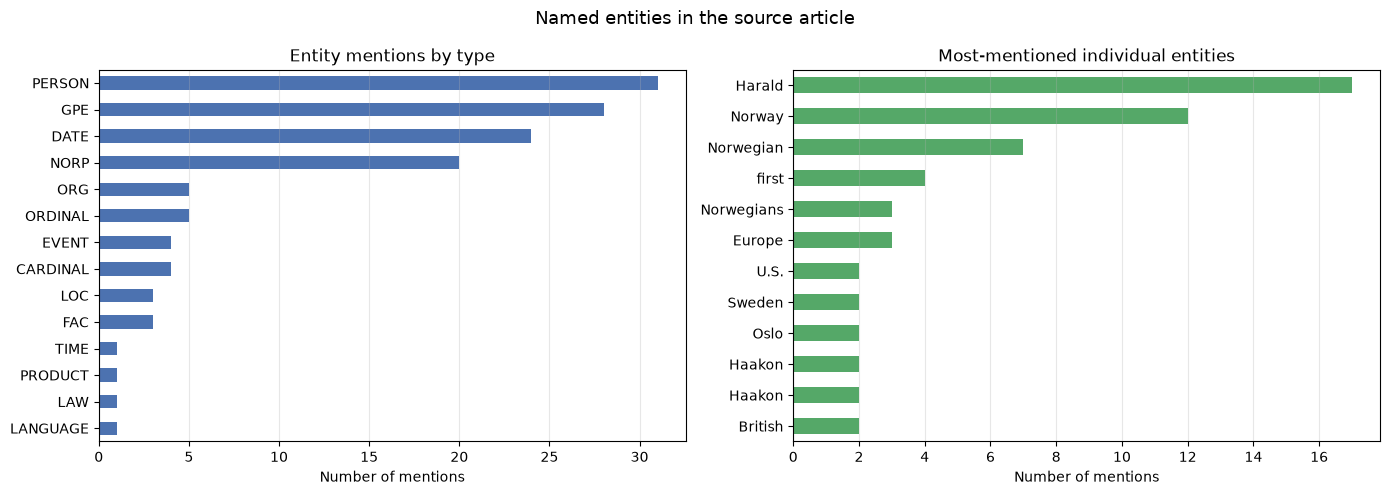

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_summary["Mentions"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Entity mentions by type")
axes[0].set_xlabel("Number of mentions")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.3)

top_entities = unique_entities.head(12).set_index("Entity")["Mentions"]
top_entities.sort_values().plot.barh(ax=axes[1], color="#55A868")
axes[1].set_title("Most-mentioned individual entities")
axes[1].set_xlabel("Number of mentions")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.3)

fig.suptitle("Named entities in the source article", fontsize=13)
fig.tight_layout()
plt.show()

### Narrative summary\n\nA short prose readout of the same table, generated from the data rather than hand-written.

In [9]:
lines = [
    f"The article contains {len(ner_df):,} entity mentions covering "
    f"{ner_df['Entity_Type'].nunique()} distinct entity types "
    f"({unique_entities.shape[0]:,} unique entities).",
    "",
]
for etype, row in type_summary.iterrows():
    lines.append(
        f"  {etype:<8} ({row['Meaning'] or 'n/a'}): "
        f"{row['Mentions']} mentions / {row['Unique_Entities']} unique "
        f"- e.g. {row['Examples']}"
    )

print("\n".join(lines))

The article contains 131 entity mentions covering 14 distinct entity types (84 unique entities).

  PERSON   (People, including fictional): 31 mentions / 14 unique - e.g. Behring Breivik, Haakon, Harald, Høiby
  GPE      (Countries, cities, states): 28 mentions / 14 unique - e.g. Afghanistan, Asker, Britain, Canada
  DATE     (Absolute or relative dates or periods): 24 mentions / 24 unique - e.g. 1370, 1905, 1928, 1937
  NORP     (Nationalities or religious or political groups): 20 mentions / 11 unique - e.g. American, British, European, German
  ORDINAL  ("first", "second", etc.): 5 mentions / 2 unique - e.g. first, second
  ORG      (Companies, agencies, institutions, etc.): 5 mentions / 4 unique - e.g. Haakon, Oxford University, Ragnhild, the National Hospital
  CARDINAL (Numerals that do not fall under another type): 4 mentions / 4 unique - e.g. 5.5 million, 77, millions, two
  EVENT    (Named hurricanes, battles, wars, sports events, etc.): 4 mentions / 3 unique - e.g. Olympics, W

## 5. Export to CSV

Three files are written:

| File | Contents |
|---|---|
| `RoshanBharati_NER_01.csv` | **Deliverable.** One row per entity mention, with `Entity` and `Entity_Type` |
| `RoshanBharati_NER_01_summary.csv` | Entity counts by category (deliverable item 4) |
| `RoshanBharati_NER_01_displacy.html` | Rendered visualisation (bonus) |

In [10]:
ner_df.to_csv(CSV_PATH, index=False, encoding="utf-8")
type_summary.to_csv(SUMMARY_PATH, encoding="utf-8")

print(f"Wrote {CSV_PATH}  ({len(ner_df):,} rows)")
print(f"Wrote {SUMMARY_PATH}  ({len(type_summary):,} rows)")

check = pd.read_csv(CSV_PATH)
assert len(check) == len(ner_df), "row count changed on round-trip"
assert {"Entity", "Entity_Type"} <= set(check.columns), "required columns missing"
print("\nRound-trip verified. Required columns as written to disk:\n")
check[["Entity", "Entity_Type"]].head(10)

Wrote output/RoshanBharati_NER_01.csv  (131 rows)
Wrote output/RoshanBharati_NER_01_summary.csv  (14 rows)

Round-trip verified. Required columns as written to disk:



,Entity,Entity_Type
0,Norway,GPE
1,Norway,GPE
2,the United States,GPE
3,Nazi,NORP
4,European,NORP
5,Friday,DATE
6,89,DATE
7,the National Hospital,ORG
8,Oslo,GPE
9,6:35 a.m.,TIME


---

## 6. Bonus A — Visualise entities with `displacy`

spaCy's `displacy` renders entity spans inline with colour-coded labels. Rendering the whole article
would be unreadable in a notebook, so the first few sentences are shown here and the **full** article
is written to an HTML file.

In [11]:
preview_doc = nlp(" ".join(s.text for s in list(doc.sents)[:6]))
displacy.render(preview_doc, style="ent", jupyter=True)

In [12]:
html = displacy.render(doc, style="ent", jupyter=False, page=True)
RENDER_PATH.write_text(html, encoding="utf-8")
print(f"Full annotated article written to {RENDER_PATH} ({len(html):,} bytes)")
print("Open it in a browser to see every entity highlighted in context.")

Full annotated article written to output/RoshanBharati_NER_01_displacy.html (45,365 bytes)
Open it in a browser to see every entity highlighted in context.


---

## 7. Bonus B — Compare two NER models

The second deliverable bonus asks us to *"compare the performance of two different NER models and
discuss the results."*

| | Model A | Model B |
|---|---|---|
| **Name** | spaCy `en_core_web_sm` | `dslim/bert-base-NER` |
| **Architecture** | CNN + transition-based parser | BERT-base fine-tuned for token classification |
| **Training data** | OntoNotes 5 | CoNLL-2003 |
| **Label set** | 18 types (`PERSON`, `GPE`, `ORG`, `DATE`, `MONEY`, …) | 4 types (`PER`, `LOC`, `ORG`, `MISC`) |
| **Size** | ~12 MB | ~430 MB |

The label sets differ, which is the central difficulty in comparing them. CoNLL-2003 has no notion of
`DATE`, `MONEY` or `CARDINAL` at all. A fair comparison therefore has to be restricted to the three
types both models can express — person, location and organisation — which is what the mapping below does.

In [13]:
import torch
from transformers import AutoModelForTokenClassification, AutoTokenizer, pipeline

MODEL_NAME = "dslim/bert-base-NER"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)

# aggregation_strategy controls how word-piece tokens are merged back into whole
# entity spans. "first" takes the label of a word's first sub-token and applies it to
# the whole word; section 7.1 below shows why that choice matters a great deal here.
bert_ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="first",
    device=-1,  # CPU
)
print(f"Loaded {MODEL_NAME} ({sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters)")

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Device set to use cpu


Loaded dslim/bert-base-NER (108M parameters)


### 7.1 — A confound worth catching first: word-piece aggregation

Before comparing anything, one decoding setting has to be pinned down, because getting it wrong
manufactures a difference that has nothing to do with model quality.

BERT does not see words; it sees **word-pieces**. Norwegian names shatter under its tokenizer:

In [14]:
for name in ["Harald", "Haakon", "Ragnhild", "Høiby", "Märtha", "Oslo"]:
    print(f"  {name:<10} -> {tokenizer.tokenize(name)}")

  Harald     -> ['Harald']
  Haakon     -> ['Ha', '##ak', '##on']
  Ragnhild   -> ['Ra', '##gn', '##hil', '##d']
  Høiby      -> ['H', '##ø', '##ib', '##y']
  Märtha     -> ['M', '##ä', '##rth', '##a']
  Oslo       -> ['Oslo']


`Harald` survives as one piece, but `Haakon` becomes `Ha ##ak ##on`. The pipeline then has to stitch
those back together, and **how** it stitches them is the `aggregation_strategy` argument:

- `"simple"` merges only pieces the model labelled consistently. When the model is confident about
  `Ha` but wavers on `##ak`, the name is emitted as *two separate entities*.
- `"first"` takes the label of the word's first sub-token and applies it across the whole word, so a
  word is never split.

The difference is not cosmetic:

In [15]:
sample = article_text[:1200]

strategy_rows = []
for strategy in ["simple", "first", "average", "max"]:
    probe = pipeline("ner", model=model, tokenizer=tokenizer,
                     aggregation_strategy=strategy, device=-1)
    found = probe(sample)
    fragments = [e["word"] for e in found
                 if e["word"].startswith("##") or len(e["word"].strip()) <= 2]
    strategy_rows.append({
        "Strategy": strategy,
        "Entities": len(found),
        "Fragments": len(fragments),
        "PER spans": ", ".join(e["word"] for e in found if e["entity_group"] == "PER")[:70],
    })

display(pd.DataFrame(strategy_rows))

print('With "simple", Haakon comes back as the two entities `Ha` and `##akon`, and')
print('STAVANGER splits into `STAV` (LOC) + `##AN` (ORG). "first" produces neither artefact.')
print('\nThis notebook therefore uses "first" - comparing spaCy against the "simple"')
print("output would have measured a tokenizer artefact rather than the model.")

Device set to use cpu


Device set to use cpu


Device set to use cpu


Device set to use cpu


,Strategy,Entities,Fragments,PER spans
0,simple,31,7,"Harald V, Harald, Ha, ##akon, Harald, O, ##lav..."
1,first,27,0,"Harald V, Harald, Haakon, Harald, Olav V, Hara..."
2,average,26,0,"Harald V, Harald, Haakon, Harald, Olav V, Hara..."
3,max,27,0,"Harald V, Harald, Haakon, Harald, Olav V, Hara..."


With "simple", Haakon comes back as the two entities `Ha` and `##akon`, and
STAVANGER splits into `STAV` (LOC) + `##AN` (ORG). "first" produces neither artefact.

This notebook therefore uses "first" - comparing spaCy against the "simple"
output would have measured a tokenizer artefact rather than the model.


### 7.2 — Running BERT over the full article

BERT has a 512 word-piece limit, so the article is fed in sentence-sized chunks and the character
offsets are mapped back onto the original text.

In [16]:
def bert_entities(text: str, max_chars: int = 1200) -> list[dict]:
    """Run the BERT NER pipeline over `text` in chunks, returning global char offsets."""
    chunks, current, start = [], "", 0
    for sent in nlp(text).sents:
        if len(current) + len(sent.text_with_ws) > max_chars and current:
            chunks.append((start, current))
            start, current = sent.start_char, sent.text_with_ws
        else:
            if not current:
                start = sent.start_char
            current += sent.text_with_ws
    if current:
        chunks.append((start, current))

    results = []
    for offset, chunk in chunks:
        for ent in bert_ner(chunk):
            results.append(
                {
                    "Entity": ent["word"].strip(),
                    "Entity_Type": ent["entity_group"],
                    "Score": round(float(ent["score"]), 4),
                    "Start_Char": offset + ent["start"],
                }
            )
    return results


bert_df = pd.DataFrame(bert_entities(article_text))
print(f"BERT found {len(bert_df):,} entity mentions across {bert_df['Entity_Type'].nunique()} types")
bert_df.head(15)

BERT found 108 entity mentions across 4 types


,Entity,Entity_Type,Score,Start_Char
0,STAVANGER,LOC,0.9836,0
1,Norway,LOC,0.9990,11
2,Harald V,PER,0.9312,25
3,Norway,LOC,0.9992,37
4,United States,LOC,0.9995,72
5,Nazi,MISC,0.9994,108
6,European,MISC,0.9997,164
7,National Hospital,LOC,0.9935,272
8,Oslo,LOC,0.9996,293
9,Harald,PER,0.9981,312


### Side-by-side type counts

In [17]:
# spaCy's OntoNotes labels folded into CoNLL's coarser scheme.
SPACY_TO_CONLL = {
    "PERSON": "PER",
    "GPE": "LOC", "LOC": "LOC", "FAC": "LOC",
    "ORG": "ORG",
    "NORP": "MISC", "EVENT": "MISC", "WORK_OF_ART": "MISC",
    "PRODUCT": "MISC", "LANGUAGE": "MISC", "LAW": "MISC",
}

spacy_mapped = ner_df.assign(Mapped=ner_df["Entity_Type"].map(SPACY_TO_CONLL))
comparable = spacy_mapped.dropna(subset=["Mapped"])

side_by_side = pd.DataFrame(
    {
        "spaCy (mapped)": comparable["Mapped"].value_counts(),
        "BERT": bert_df["Entity_Type"].value_counts(),
    }
).fillna(0).astype(int)
side_by_side["Difference"] = side_by_side["spaCy (mapped)"] - side_by_side["BERT"]
side_by_side.loc["TOTAL"] = side_by_side.sum()
side_by_side

,spaCy (mapped),BERT,Difference
LOC,34,34,0
MISC,27,27,0
ORG,5,1,4
PER,31,46,-15
TOTAL,97,108,-11


### Where the two models agree and disagree

Agreement is measured on **unique entity strings** rather than mentions, so a name repeated ten times
does not count ten times toward the score.

In [18]:
def normkey(s: str) -> str:
    """Lowercase, strip possessives and punctuation so 'Harald's' == 'Harald'."""
    return re.sub(r"[^a-z0-9 ]", "", s.lower().replace("'s", "")).strip()


spacy_set = {normkey(e) for e in comparable["Entity"] if normkey(e)}
bert_set = {normkey(e) for e in bert_df["Entity"] if normkey(e)}

both = spacy_set & bert_set
only_spacy = spacy_set - bert_set
only_bert = bert_set - spacy_set

print(f"Found by both models : {len(both):>3}")
print(f"Only spaCy           : {len(only_spacy):>3}")
print(f"Only BERT            : {len(only_bert):>3}")
print(f"Jaccard agreement    : {len(both) / len(spacy_set | bert_set):.1%}")

print("\nSample found by both      :", ", ".join(sorted(both)[:8]))
print("Sample only spaCy found   :", ", ".join(sorted(only_spacy)[:8]))
print("Sample only BERT found    :", ", ".join(sorted(only_bert)[:8]))

Found by both models :  38
Only spaCy           :  13
Only BERT            :  17
Jaccard agreement    : 55.9%

Sample found by both      : afghanistan, american, asker, astrid, britain, british, canada, denmark
Sample only spaCy found   : behring breivik, crown princess mettemarit, king haakon viii, louise, mettemarit, olav iv, royal, the national hospital
Sample only BERT found    : allah, anders behring breivik, god, harald v, lgbtq, margrethe, marit, mette


In [19]:
# Cases where both models found the entity but assigned different types.
spacy_types = {normkey(r.Entity): r.Mapped for r in comparable.itertuples()}
bert_types = {normkey(r.Entity): r.Entity_Type for r in bert_df.itertuples()}

conflicts = pd.DataFrame(
    [
        {"Entity": k, "spaCy (mapped)": spacy_types[k], "BERT": bert_types[k]}
        for k in sorted(both)
        if spacy_types[k] != bert_types[k]
    ]
)

if conflicts.empty:
    print("The two models assigned the same type to every entity they both detected.")
else:
    print(f"{len(conflicts)} entities received conflicting types:\n")
    display(conflicts)

agreed = len(both) - len(conflicts)
print(f"\nType agreement on jointly-detected entities: {agreed}/{len(both)} = {agreed / len(both):.1%}")

3 entities received conflicting types:



,Entity,spaCy (mapped),BERT
0,astrid,MISC,PER
1,olympic,LOC,MISC
2,ragnhild,ORG,PER



Type agreement on jointly-detected entities: 35/38 = 92.1%


### Discussion

**Label sets explain most of the raw gap.** spaCy reports 14 entity types against BERT's 4. The
`DATE` (24 mentions), `NORP` (20), `CARDINAL` and `ORDINAL` categories have no CoNLL-2003 equivalent,
so BERT cannot produce them at any level of skill. Once folded to the shared PER/LOC/ORG/MISC scheme,
`LOC` and `MISC` come out **exactly equal (34 and 27)**. The headline difference in total mentions is
a taxonomy artefact, not a capability difference.

**Where they genuinely diverge: multi-word titles.** The remaining PER gap is about span boundaries,
and neither model wins cleanly:

- Only spaCy recovered the full honorifics — `king haakon viii`, `crown princess mette-marit`,
  `olav iv`, and the organisation `the national hospital`.
- Only BERT recovered `anders behring breivik` in full; spaCy clipped it to `behring breivik`, losing
  the first name. BERT also kept `harald v` together as one span.

So spaCy is stronger on *titles* (rank + name + numeral) and BERT is stronger on *plain personal
names*. BERT's residual excess in the PER column is largely partial spans — `margrethe`, `marit`,
`mette` — emitted alongside the fuller name rather than instead of it.

**Type conflicts favour BERT.** Of the 38 entities both models detected, 35 received the same type
(92.1%). All three disagreements are worth looking at individually:

| Entity | spaCy | BERT | Who is right |
|---|---|---|---|
| `Ragnhild` | ORG | PER | **BERT.** Princess Ragnhild is a person; spaCy's ORG is a clear error. |
| `Astrid` | MISC | PER | **BERT.** Princess Astrid, likewise. |
| `Olympic` | LOC | MISC | Neither — a genuine OntoNotes/CoNLL convention difference. |

That is a real quality signal rather than a taxonomy artefact: spaCy's small model mis-types Norwegian
royal given names that BERT handles correctly, most likely because those names are rare in OntoNotes
but the surrounding syntactic context is enough for a contextual model.

**The methodological finding is section 7.1.** The most consequential result here was not about either
model. `aggregation_strategy="simple"` — the setting most tutorials use — silently shattered every
Norwegian name: `Haakon` came back as the two entities `Ha` and `##akon`, `STAVANGER` as `STAV` (LOC)
plus `##AN` (ORG). Under that setting BERT scored 31 entities with 7 fragments and Jaccard agreement
was 39.8%; switching to `"first"` gave 27 entities, **zero** fragments, and 55.9% agreement. Had the
comparison been run without checking, it would have "demonstrated" that BERT is bad at non-English
person names, and that conclusion would have been entirely an artefact of a decoding hyperparameter.

**Cost.** spaCy is ~12 MB and tags the full article in well under a second on CPU. BERT is ~430 MB and
takes roughly two orders of magnitude longer for this document.

**Conclusion.** For this specific assignment spaCy is the better tool, mainly because the required CSV
asks for `DATE` alongside `PERSON`, `GPE` and `ORG` — a label set BERT structurally cannot emit — and
because it keeps royal titles intact at 1/35th the size. But BERT is measurably more accurate on the
one axis where both can be scored, entity *typing* of people, and it would be the right choice for a
pipeline that only needs the four coarse types on unfamiliar names. Neither model dominates; the
label set the downstream task requires decides it.

---

## 8. Results

In [20]:
print(f"Article           : {header.splitlines()[0]}")
print(f"Words             : {len(article_text.split()):,}")
print(f"Entity mentions   : {len(ner_df):,}")
print(f"Unique entities   : {len(unique_entities):,}")
print(f"Entity types      : {ner_df['Entity_Type'].nunique()}")
print(f"Most common type  : {type_summary.index[0]} ({type_summary.iloc[0]['Mentions']} mentions)")
print(f"Most-named entity : {unique_entities.iloc[0]['Entity']} "
      f"({unique_entities.iloc[0]['Mentions']} mentions)")
print(f"\nDeliverable       : {CSV_PATH}")
print(f"Summary           : {SUMMARY_PATH}")
print(f"Visualisation     : {RENDER_PATH}")

Article           : Norway's King Harald V dies at 89 and his son becomes King Haakon VIII
Words             : 991
Entity mentions   : 131
Unique entities   : 84
Entity types      : 14
Most common type  : PERSON (31 mentions)
Most-named entity : Harald (17 mentions)

Deliverable       : output/RoshanBharati_NER_01.csv
Summary           : output/RoshanBharati_NER_01_summary.csv
Visualisation     : output/RoshanBharati_NER_01_displacy.html


### Deliverables checklist

- [x] Jupyter notebook — `RoshanBharati_NER_01.ipynb`
- [x] Original article text — `data/news_article.txt`
- [x] Extracted named entities — `output/RoshanBharati_NER_01.csv` (`Entity`, `Entity_Type`, …)
- [x] Summary of entity counts by category — section 4 and `output/RoshanBharati_NER_01_summary.csv`
- [x] *Bonus:* `displacy` visualisation — section 6 and `output/RoshanBharati_NER_01_displacy.html`
- [x] *Bonus:* two-model comparison and discussion — section 7